#Считывание и предобработка данных

Обработка записей с NaN: если в записи о плавке нет данных о содержании хотя бы одного элемента в полупродукте, то такая запись не может использоваться для анализа и построения модели


In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)

ds1 = pd.read_excel('/content/PQM - podatki za pilotni projekt (OCR12VM) - ENG.xlsx', sheet_name='Table1 (basic)', header=1)
ds1.drop(['QualityRequirement','QualNo','CustID','CustVer','InternalVer','MetalRavneQualityName','SteelGroup','Month','Year'], axis=1, inplace=True)
print(f'Исходное кол-во записей в датасете с первого листа: {len(ds1)}')
ds1.drop_duplicates(subset=['HeatNo'], keep='first', inplace=True)

print(f"Уникальных HeatNo после удаления дублирующихся записей в первом листе: {ds1['HeatNo'].nunique()}")
ds1.dropna(subset=['Cr_Last_EOP','Mo_Last_EOP','Ni_Last_EOP','V_Last_EOP','W_Last_EOP'], how='any', inplace=True)
print(f"Уникальных HeatNo после обработки пропусков в первом листе: {ds1['HeatNo'].nunique()}")


ds2 = pd.read_excel('/content/PQM - podatki za pilotni projekt (OCR12VM) - ENG.xlsx', sheet_name='Table2 (limits)', header=1)
ds2.drop(['QualityRequirement','QualNo','CustID','CustVer','InternalVer','MetalRavneQualityName','SteelGroup','Month','Year'],axis=1,inplace=True)
ds2.drop(['Date', 'Cr_Final', 'Ni_Final', 'Mo_Final', 'V_Final', 'W_Final'], axis=1, inplace=True)
print(f'\nИсходное кол-во записей в датасете со второго листа: {len(ds2)}')
ds2.drop_duplicates(subset=['HeatNo'], keep='first', inplace=True)
print(f"Уникальных HeatNo после удаления дублирующихся записей во втором листе: {ds2['HeatNo'].nunique()}")

df = ds1.merge(ds2, on='HeatNo', how='inner')
print(f'\nДлина датасета (объединенного 1 и 2) после обработки пропусков: {len(df)}\n')

ds4 = pd.read_excel('/content/PQM - podatki za pilotni projekt (OCR12VM) - ENG.xlsx', sheet_name='Table4 (alloys)', header=1)
ds4.drop_duplicates(subset=['HeatNo'], keep='first', inplace=True)

df.drop(['LFVD_FeCrA', 'LFVD_FeCrC','LFVD_NiGran', 'LFVD_NiKatode','LFVD_FeMo', 'LFVD_Polymox','LFVD_FeV','LFVD_FeW72','LFVD_WPaketi'], axis=1, inplace=True)
df = df.merge(ds4, on='HeatNo', how='inner')

ds8 = pd.read_excel('/content/PQM - podatki za pilotni projekt (OCR12VM) - ENG.xlsx', sheet_name='Table8 (scrap)', header=1)
ds8.drop_duplicates(subset=['HeatNo'], keep='first', inplace=True)
df=df.merge(ds8,on='HeatNo',how='inner')

ds9 = pd.read_excel('/content/PQM - podatki za pilotni projekt (OCR12VM) - ENG.xlsx', sheet_name='Table9 (all. scr.)', header=1)
ds9.drop_duplicates(subset=['HeatNo'], keep='first', inplace=True)
df=df.merge(ds9,on='HeatNo',how='inner')

ds10 = pd.read_excel('/content/PQM - podatki za pilotni projekt (OCR12VM) - ENG.xlsx', sheet_name='Table10 (unall. scr.)', header=1)
ds10.drop_duplicates(subset=['HeatNo'], keep='first', inplace=True)
df=df.merge(ds10,on='HeatNo',how='inner')

print(f'Всего столбцов в датасете после объединения всех нужных таблиц: {len(df.columns)}, всего строк: {len(df)} ')
df.head(10)

Исходное кол-во записей в датасете с первого листа: 3610
Уникальных HeatNo после удаления дублирующихся записей в первом листе: 3590
Уникальных HeatNo после обработки пропусков в первом листе: 3233

Исходное кол-во записей в датасете со второго листа: 3606
Уникальных HeatNo после удаления дублирующихся записей во втором листе: 3590

Длина датасета (объединенного 1 и 2) после обработки пропусков: 3233

Всего столбцов в датасете после объединения всех нужных таблиц: 220, всего строк: 3225 


,HeatNo,Date,TotalIngotsWeight,PouringScrap,OtherScrap,Last_EOP,Cr_Last_EOP,Cr_Final,Ni_Last_EOP,Ni_Final,Mo_Last_EOP,Mo_Final,V_Last_EOP,V_Final,W_Last_EOP,W_Final,Cr_LowerLimit,Cr_Target,Cr_UpperLimit,Ni_LowerLimit,Ni_Target,Ni_UpperLimit,Mo_LowerLimit,Mo_Target,Mo_UpperLimit,V_LowerLimit,V_Target,V_UpperLimit,W_LowerLimit,W_Target,W_UpperLimit,LFVD_AlBloki,LFVD_AlGran,LFVD_Boksit,LFVD_CaO,LFVD_CaSi,LFVD_CASIfi13,LFVD_Cfi13,LFVD_CoMet,LFVD_Cu,LFVD_EPŽŽlindra,LFVD_FeAl,LFVD_FeB,LFVD_FeBŽica,LFVD_FeCrNit,LFVD_FeCrA,LFVD_FeCrC,LFVD_FeCrCSi,LFVD_FeCrC51,LFVD_FeMnA,LFVD_FeMnC,LFVD_FeMo,LFVD_FeNbTa,LFVD_FeNbTafi13,LFVD_FeS,LFVD_FeSi,LFVD_FeSiZrŽica,LFVD_FeTi,LFVD_FeTifi13,LFVD_FeV,LFVD_FeW72,LFVD_KarboritMleti,LFVD_MnMet,LFVD_NiGran,LFVD_NiKatode,LFVD_NiOksid,LFVD_OdpCu,LFVD_Polymox,LFVD_SŽica,LFVD_SiMet,LFVD_SiMn,LFVD_SLAGMAG65B,LFVD_KarboritZaVpih,LFVD_Ni90,LFVD_AlŽica,LFVD_Molyquick,LFVD_AlOplašèenaŽica,LFVD_BelaŽlindra,LFVD_Kisik,LFVD_KalcijevKarbid,LFVD_WPaketi,LFVD_SintŽlindra,Fill#1_ScrapName,Fill#1_ScrapWeight,Fill#2_ScrapName,Fill#2_ScrapWeight,Fill#3_ScrapName,Fill#3_ScrapWeight,Fill#4_ScrapName,Fill#4_ScrapWeight,Fill#5_ScrapName,Fill#5_ScrapWeight,Fill#6_ScrapName,Fill#6_ScrapWeight,PV_MKK,PV_PO102,PV_OCR12SPW,PV_OCR8W,PV_PO180,PV_PT181,PV_PT202,PV_PT212,PV_OH239,PV_OSIKRO3,PV_OW4,PV_OCR8VMS,PV_CRV3,PV_OH250,PV_OH252,PV_OH255,PV_OH257,PV_OH258,PV_OH260,PV_OH236NI,PV_UTOPMONI,PV_PKTB,PV_PK3NI,PV_PK332,PV_PK335,PV_PK338,PV_PK340,PV_PK11S,PV_PK343,PV_18MNCR4,PV_PK346,PV_INVAR36,PV_EMCR,PV_SIVA_LITINA,PV_CK10,PV_OC100EX,PV_EC80,PV_VCMO140,PV_VCMO230,PV_31CRV3,PV_ECN150,PV_ECN35,PV_VCNMO200,PV_UTOPNICU,PV_OH807,PV_OCR4PR,PV_OCR12,PV_OCR12SP,PV_OCR12EX,PV_CRV,PV_TMCN2,PV_TMCN1,PV_OSIKRO4,PV_OW1,PV_OCR12VM,PV_CRV2,PV_OSV1,PV_OW6,PV_145V33,PV_UTOP3,PV_UTOPMO2,PV_UTOPEX1,PV_UTOP1,PV_UTOP2,PV_UTOPCO,PV_UTOPEX3,PV_UTOPMO4,PV_UTOPCO2,PV_OV862,PV_UTOPMO6,PV_UTOP33,PV_UTOPSP,PV_UTOPCO3,PV_BRW,PV_BRW1,PV_BRC,PV_BRM2,PV_BRM1,PV_BRM,PV_BRCV,PV_BRC3,PV_BRU,PV_BRCMO,PV_BRCMO2,PV_UTOPTI,PV_12MN,PV_PK2,PV_RAVNIN2,PV_RAVNIN3,PV_RAVNIN4,PV_PK2SP,PV_PK11,PV_PK12,PV_PK13,PV_PKAS,PV_PK15,PV_PK19,PV_PK20,PV_PT929,PV_PK5,PV_PK5M,PV_28304N,PV_PK939,PV_X45,PV_PK942,PV_RAVNAL2,PV_PK10,PV_19MNCR18,PV_214N,PV_OCR8W_OSTRUŽKI,PV_CRV3_OSTRUŽKI,PV_PK335_OSTRUŽKI,PV_CRMO_OSTRUŽKI,PV_CRMO_DROBIŽ,PV_VCNMO200_DROBIŽ,PV_TMCN2_OSTRUŽKI,PV_OCR12VM_OSTRUŽKI,PV_POSEBNA_JEKLA_OSTRUŽKI,PV_BRM2_OSTRUŽKI,PV_E1,PV_E3,PV_E6,PV_E8,PV_Kore,PV_GRODELJ,PV_E40
0,73579,2004-07-27 00:17:10,49440.0,600.0,2000.0,2.0,9.71,11.30,0.20,0.21,0.12,0.71,0.03,0.90,0.01,0.02,11.1,11.26,11.75,0,0,0.25,0.70,0.73,0.80,0.90,0.93,1.00,0,0,0.20,26,0,200,600,0,16.5,20.6,0,0,0,0,0,0,0,0,2400,0,0,0,20,520,0,0,0,130,0,0,0,580,0,125,0,0,0,0,0,0,0.0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,E3,40000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,40000,0,0,0,0,0
1,73580,2004-07-27 02:18:07,46800.0,1000.0,100.0,3.0,12.41,11.75,0.16,0.16,0.08,0.85,0.04,0.29,0.01,0.02,11.5,11.65,12.00,0,0,0.30,0.70,0.73,0.80,0.90,0.95,1.00,0,0,0.20,20,0,100,500,0,16.5,0.0,0,0,0,0,0,0,0,0,1200,0,0,0,100,625,0,0,0,55,0,0,0,135,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,E3,40200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,40200,0,0,0,0,0
2,73581,2004-07-27 04:46:58,45320.0,800.0,2000.0,3.0,11.24,11.63,0.17,0.18,0.07,0.72,0.04,0.91,0.01,0.02,11.5,11.65,12.00,0,0,0.30,0.70,0.73,0.80,0.90,0.95,1.00,0,0,0.20,15,0,70,400,0,16.5,0.0,0,0,0,0,0,0,0,0,2000,0,0,0,0,490,0,0,0,80,0,0,0,520,0,50,0,0,0,0,0,0,0.0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,E3,40200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

Удаление данных в которых дисперсия равна нулю (такие признаки неинформативны)

In [ ]:
df.describe()

,HeatNo,Date,TotalIngotsWeight,PouringScrap,OtherScrap,Last_EOP,Cr_Last_EOP,Cr_Final,Ni_Last_EOP,Ni_Final,Mo_Last_EOP,Mo_Final,V_Last_EOP,V_Final,W_Last_EOP,W_Final,Cr_LowerLimit,Cr_Target,Cr_UpperLimit,Ni_LowerLimit,Ni_Target,Ni_UpperLimit,Mo_LowerLimit,Mo_Target,Mo_UpperLimit,V_LowerLimit,V_Target,V_UpperLimit,W_LowerLimit,W_Target,W_UpperLimit,LFVD_AlBloki,LFVD_AlGran,LFVD_Boksit,LFVD_CaO,LFVD_CaSi,LFVD_CASIfi13,LFVD_Cfi13,LFVD_CoMet,LFVD_Cu,LFVD_EPŽŽlindra,LFVD_FeAl,LFVD_FeB,LFVD_FeBŽica,LFVD_FeCrNit,LFVD_FeCrA,LFVD_FeCrC,LFVD_FeCrCSi,LFVD_FeCrC51,LFVD_FeMnA,LFVD_FeMnC,LFVD_FeMo,LFVD_FeNbTa,LFVD_FeNbTafi13,LFVD_FeS,LFVD_FeSi,LFVD_FeSiZrŽica,LFVD_FeTi,LFVD_FeTifi13,LFVD_FeV,LFVD_FeW72,LFVD_KarboritMleti,LFVD_MnMet,LFVD_NiGran,LFVD_NiKatode,LFVD_NiOksid,LFVD_OdpCu,LFVD_Polymox,LFVD_SŽica,LFVD_SiMet,LFVD_SiMn,LFVD_SLAGMAG65B,LFVD_KarboritZaVpih,LFVD_Ni90,LFVD_AlŽica,LFVD_Molyquick,LFVD_AlOplašèenaŽica,LFVD_BelaŽlindra,LFVD_Kisik,LFVD_KalcijevKarbid,LFVD_WPaketi,LFVD_SintŽlindra,Fill#1_ScrapWeight,Fill#2_ScrapWeight,Fill#3_ScrapWeight,Fill#4_ScrapWeight,Fill#5_ScrapWeight,Fill#6_ScrapWeight,PV_MKK,PV_PO102,PV_OCR12SPW,PV_OCR8W,PV_PO180,PV_PT181,PV_PT202,PV_PT212,PV_OH239,PV_OSIKRO3,PV_OW4,PV_OCR8VMS,PV_CRV3,PV_OH250,PV_OH252,PV_OH255,PV_OH257,PV_OH258,PV_OH260,PV_OH236NI,PV_UTOPMONI,PV_PKTB,PV_PK3NI,PV_PK332,PV_PK335,PV_PK338,PV_PK340,PV_PK11S,PV_PK343,PV_18MNCR4,PV_PK346,PV_INVAR36,PV_EMCR,PV_SIVA_LITINA,PV_CK10,PV_OC100EX,PV_EC80,PV_VCMO140,PV_VCMO230,PV_31CRV3,PV_ECN150,PV_ECN35,PV_VCNMO200,PV_UTOPNICU,PV_OH807,PV_OCR4PR,PV_OCR12,PV_OCR12SP,PV_OCR12EX,PV_CRV,PV_TMCN2,PV_TMCN1,PV_OSIKRO4,PV_OW1,PV_OCR12VM,PV_CRV2,PV_OSV1,PV_OW6,PV_145V33,PV_UTOP3,PV_UTOPMO2,PV_UTOPEX1,PV_UTOP1,PV_UTOP2,PV_UTOPCO,PV_UTOPEX3,PV_UTOPMO4,PV_UTOPCO2,PV_OV862,PV_UTOPMO6,PV_UTOP33,PV_UTOPSP,PV_UTOPCO3,PV_BRW,PV_BRW1,PV_BRC,PV_BRM2,PV_BRM1,PV_BRM,PV_BRCV,PV_BRC3,PV_BRU,PV_BRCMO,PV_BRCMO2,PV_UTOPTI,PV_12MN,PV_PK2,PV_RAVNIN2,PV_RAVNIN3,PV_RAVNIN4,PV_PK2SP,PV_PK11,PV_PK12,PV_PK13,PV_PKAS,PV_PK15,PV_PK19,PV_PK20,PV_PT929,PV_PK5,PV_PK5M,PV_28304N,PV_PK939,PV_X45,PV_PK942,PV_RAVNAL2,PV_PK10,PV_19MNCR18,PV_214N,PV_OCR8W_OSTRUŽKI,PV_CRV3_OSTRUŽKI,PV_PK335_OSTRUŽKI,PV_CRMO_OSTRUŽKI,PV_CRMO_DROBIŽ,PV_VCNMO200_DROBIŽ,PV_TMCN2_OSTRUŽKI,PV_OCR12VM_OSTRUŽKI,PV_POSEBNA_JEKLA_OSTRUŽKI,PV_BRM2_OSTRUŽKI,PV_E1,PV_E3,PV_E6,PV_E8,PV_Kore,PV_GRODELJ,PV_E40
count,3225.000000,3225,3225.000000,3219.000000,3213.000000,3225.000000,3225.000000,3225.000000,3225.000000,3225.000000,3225.000000,3225.000000,3225.000000,3225.000000,3225.000000,3225.000000,3225.000000,3225.000000,3225.000000,3225.0,3225.0,3225.00000,3225.000000,3225.000000,3225.000000,3225.000000,3225.000000,3225.000000,3225.0,3225.0,3225.000000,3225.000000,3225.000000,3225.000000,3225.000000,3225.0,3225.000000,3225.000000,3225.0,3225.0,3225.000000,3225.000000,3225.0,3225.0,3225.0,3225.000000,3225.000000,3225.000000,3225.000000,3225.0,3225.000000,3225.000000,3225.0,3225.0,3225.000000,3225.000000,3225.0,3225.0,3225.0,3225.000000,3225.000000,3225.000000,3225.000000,3225.000000,3225.0,3225.0,3225.0,3225.000000,3225.000000,3225.0,3225.000000,3225.000000,3225.0,3225.0,3225.000000,3225.0,3225.000000,3225.000000,3225.0,3225.000000,3225.0,3225.000000,3225.000000,2958.000000,2827.000000,980.000000,39.000000,1.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.000000,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.000000,3225.000000,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.000000,3225.0,3225.0,3225.0,3225.0,3225.0,3225.000000,3225.000000,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.000000,3225.000000,3225.0,3225.000000,3225.0,3225.0,3225.0,3225.0,3225.000000,3225.0,3225.0,3225.0,3225.0,3225.0,3225.000000,3225.0,3225.0,3225.0,3225.0,3225.0,3225.000000,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.000000,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.0,3225.

In [ ]:
del_=[]
for i in df.describe().columns:
    if df.describe().loc['std',i] == 0:
        del_.append(i)

del_.remove('Ni_LowerLimit')
del_.remove('Ni_Target')
del_.remove('W_LowerLimit')
del_.remove('W_Target')

df.drop(del_,axis=1,inplace=True)
df.drop(['Fill#1_ScrapName','Fill#1_ScrapWeight','Fill#2_ScrapName','Fill#2_ScrapWeight','Fill#3_ScrapName','Fill#3_ScrapWeight','Fill#4_ScrapName',
          'Fill#4_ScrapWeight','Fill#5_ScrapName','Fill#5_ScrapWeight','Fill#6_ScrapName','Fill#6_ScrapWeight'],axis=1,inplace=True)

print(f'Всего столбцов в итоговом датасете: {len(df.columns)}, всего строк: {len(df)} ')

data = df.copy()
print(f'data создан: {len(data.columns)} столбцов, {len(data)} строк')

Всего столбцов в итоговом датасете: 81, всего строк: 3225 
data создан: 81 столбцов, 3225 строк


In [ ]:
df.head(3)

,HeatNo,Date,TotalIngotsWeight,PouringScrap,OtherScrap,Last_EOP,Cr_Last_EOP,Cr_Final,Ni_Last_EOP,Ni_Final,Mo_Last_EOP,Mo_Final,V_Last_EOP,V_Final,W_Last_EOP,W_Final,Cr_LowerLimit,Cr_Target,Cr_UpperLimit,Ni_LowerLimit,Ni_Target,Ni_UpperLimit,Mo_LowerLimit,Mo_Target,Mo_UpperLimit,V_LowerLimit,V_Target,V_UpperLimit,W_LowerLimit,W_Target,W_UpperLimit,LFVD_AlBloki,LFVD_AlGran,LFVD_Boksit,LFVD_CaO,LFVD_CASIfi13,LFVD_Cfi13,LFVD_EPŽŽlindra,LFVD_FeAl,LFVD_FeCrA,LFVD_FeCrC,LFVD_FeCrCSi,LFVD_FeCrC51,LFVD_FeMnC,LFVD_FeMo,LFVD_FeS,LFVD_FeSi,LFVD_FeV,LFVD_FeW72,LFVD_KarboritMleti,LFVD_MnMet,LFVD_NiGran,LFVD_Polymox,LFVD_SŽica,LFVD_SiMn,LFVD_SLAGMAG65B,LFVD_AlŽica,LFVD_AlOplašèenaŽica,LFVD_BelaŽlindra,LFVD_KalcijevKarbid,LFVD_SintŽlindra,PV_PT181,PV_OH252,PV_OH255,PV_EMCR,PV_VCMO230,PV_31CRV3,PV_OCR12,PV_OCR12SP,PV_CRV,PV_OCR12VM,PV_UTOPMO2,PV_UTOPMO4,PV_PK2,PV_PK5,PV_PK5M,PV_CRMO_OSTRUŽKI,PV_OCR12VM_OSTRUŽKI,PV_E3,PV_E6,PV_E8
0,73579,2004-07-27 00:17:10,49440.0,600.0,2000.0,2.0,9.71,11.30,0.20,0.21,0.12,0.71,0.03,0.90,0.01,0.02,11.1,11.26,11.75,0,0,0.25,0.7,0.73,0.8,0.9,0.93,1.0,0,0,0.2,26,0,200,600,16.5,20.6,0,0,0,2400,0,0,20,520,0,130,580,0,125,0,0,0,0.0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,40000,0,0
1,73580,2004-07-27 02:18:07,46800.0,1000.0,100.0,3.0,12.41,11.75,0.16,0.16,0.08,0.85,0.04,0.29,0.01,0.02,11.5,11.65,12.00,0,0,0.30,0.7,0.73,0.8,0.9,0.95,1.0,0,0,0.2,20,0,100,500,16.5,0.0,0,0,0,1200,0,0,100,625,0,55,135,0,0,0,0,0,0.0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,40200,0,0
2,73581,2004-07-27 04:46:58,45320.0,800.0,2000.0,3.0,11.24,11.63,0.17,0.18,0.07,0.72,0.04,0.91,0.01,0.02,11.5,11.65,12.00,0,0,0.30,0.7,0.73,0.8,0.9,0.95,1.0,0,0,0.2,15,0,70,400,16.5,0.0,0,0,0,2000,0,0,0,490,0,80,520,0,50,0,0,0,0.0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,40200,0,0


Проверка взаимных корреляций числовых признаков

In [ ]:
df_cop = df.copy()
df_cop = df_cop.drop(['HeatNo','Date'],axis=1)
corr = df_cop.corr()
print('Число столбцов в таблице =', len(corr))
display(corr)

gran_corr_value = 0.8
corr_={i:[] for i in corr.columns}
for i in range(len(corr.columns)):
    mas=corr[corr.columns[i]].tolist()
    el=mas[i]
    ind_max=[j for j in range(len(mas)) if (mas[j]>gran_corr_value)&(j!=i)]
    mas.remove(mas[i])
    corr_[corr.columns[i]]=[min(mas),max(mas)]+[corr.columns[j] for j in ind_max]
    print(corr.columns[i],':',corr_[corr.columns[i]])

Число столбцов в таблице = 79


,TotalIngotsWeight,PouringScrap,OtherScrap,Last_EOP,Cr_Last_EOP,Cr_Final,Ni_Last_EOP,Ni_Final,Mo_Last_EOP,Mo_Final,V_Last_EOP,V_Final,W_Last_EOP,W_Final,Cr_LowerLimit,Cr_Target,Cr_UpperLimit,Ni_LowerLimit,Ni_Target,Ni_UpperLimit,Mo_LowerLimit,Mo_Target,Mo_UpperLimit,V_LowerLimit,V_Target,V_UpperLimit,W_LowerLimit,W_Target,W_UpperLimit,LFVD_AlBloki,LFVD_AlGran,LFVD_Boksit,LFVD_CaO,LFVD_CASIfi13,LFVD_Cfi13,LFVD_EPŽŽlindra,LFVD_FeAl,LFVD_FeCrA,LFVD_FeCrC,LFVD_FeCrCSi,LFVD_FeCrC51,LFVD_FeMnC,LFVD_FeMo,LFVD_FeS,LFVD_FeSi,LFVD_FeV,LFVD_FeW72,LFVD_KarboritMleti,LFVD_MnMet,LFVD_NiGran,LFVD_Polymox,LFVD_SŽica,LFVD_SiMn,LFVD_SLAGMAG65B,LFVD_AlŽica,LFVD_AlOplašèenaŽica,LFVD_BelaŽlindra,LFVD_KalcijevKarbid,LFVD_SintŽlindra,PV_PT181,PV_OH252,PV_OH255,PV_EMCR,PV_VCMO230,PV_31CRV3,PV_OCR12,PV_OCR12SP,PV_CRV,PV_OCR12VM,PV_UTOPMO2,PV_UTOPMO4,PV_PK2,PV_PK5,PV_PK5M,PV_CRMO_OSTRUŽKI,PV_OCR12VM_OSTRUŽKI,PV_E3,PV_E6,PV_E8
TotalIngotsWeight,1.000000,0.193895,-0.254886,-0.018212,-0.030634,-0.006719,-0.001496,0.017638,-0.019188,-0.019662,-0.030408,-0.085185,0.010512,0.008139,0.011415,-0.009487,0.044226,NaN,NaN,0.052162,-0.007620,-0.014656,-0.010016,-0.082824,-0.083237,-0.072390,NaN,NaN,0.015322,0.117310,0.075504,-0.002983,0.019300,0.026139,0.104301,-0.001430,0.023374,-0.016840,0.154830,0.037690,0.001116,0.011485,0.094345,0.000748,0.007549,0.091858,-0.029697,0.018623,0.007585,0.001303,0.000867,0.034084,-0.012471,0.018171,0.010136,0.113065,-0.011756,-0.055413,-0.037188,0.024510,-0.020089,-0.007655,0.004603,0.002133,0.004109,-0.020885,0.000748,0.050590,0.021040,-0.029266,-0.010435,-0.019608,0.026790,0.033805,0.008428,0.074344,-0.049151,0.096614,-0.024993
PouringScrap,0.193895,1.000000,-0.078162,0.017521,0.031799,0.088103,0.002218,-0.003991,0.021256,0.059037,-0.054236,0.006268,-0.012892,0.000405,0.114075,0.083393,0.092884,NaN,NaN,-0.018930,0.084875,0.075294,-0.004290,0.014989,0.016541,0.004596,NaN,NaN,-0.048025,0.023879,-0.026827,-0.037235,0.008958,0.038870,0.028632,0.026349,0.024098,0.002625,0.034857,0.032957,-0.054380,0.025322,0.020552,-0.030617,-0.005295,0.074667,-0.013064,-0.001249,-0.032557,0.001658,0.021640,0.031672,0.005427,0.017456,-0.026377,0.018040,0.018342,0.048341,0.039906,0.021931,-0.000674,0.003962,-0.031936,0.033234,0.017507,-0.000646,-0.012378,0.058317,-0.073148,0.036168,0.009558,0.008510,-0.011251,-0.017526,0.012150,-0.021198,-0.000013,0.045710,-0.031286
OtherScrap,-0.254886,-0.078162,1.000000,-0.036516,-0.024331,-0.019767,0.036869,0.045214,0.021680,0.019361,0.003034,0.037111,0.027097,0.029374,0.005674,0.006331,0.001780,NaN,NaN,-0.022400,0.010236,0.016763,0.010006,0.033171,0.032709,0.032081,NaN,NaN,-0.009469,0.000931,-0.011348,-0.019453,0.004866,0.007424,0.030614,-0.025415,-0.020334,0.057823,0.108631,0.041998,-0.021454,-0.039779,-0.001810,-0.005648,0.040637,0.058053,0.042075,-0.015631,-0.011972,0.020997,-0.008418,-0.011522,0.014011,0.022476,-0.029652,-0.017027,0.026149,-0.048462,-0.006088,-0.004518,-0.014324,0.013203,0.017464,0.017276,0.026192,0.013546,0.032905,-0.002094,0.014537,0.004309,-0.002781,0.039013,-0.018009,-0.008263,-0.000744,0.002466,-0.033679,0.002294,0.002639
Last_EOP,-0.018212,0.017521,-0.036516,1.000000,0.051873,0.087748,-0.020518,-0.043458,-0.004249,0.030086,-0.120657,0.077769,-0.018816,-0.024652,0.077712,0.065786,0.052576,NaN,NaN,-0.025160,0.001408,0.004583,-0.050914,0.083333,0.086947,0.076730,NaN,NaN,-0.030053,0.024863,-0.012226,0.002289,0.054801,0.071255,0.038596,0.013891,-0.006496,-0.000103,-0.055315,-0.011095,0.003234,0.018178,-0.003442,-0.006496,0.089840,0.126769,-0.010583,0.114949,-0.011152,0.001935,0.006603,0.010354,0.051380,-0.022385,0.020179,-0.025001,0.012910,-0.028745,0.001768,0.068728,0.018606,0.018767,0.008331,-0.021579,0.035582,-0.009416,-0.006496,0.015479,-0.116889,-0.000130,-0.021290,0.023770,-0.028708,-0.043584,0.027729,-0.127203,0.198823,-0.074475,0.009381
Cr_Last_EOP,-0.030634,0.031799,-0.024331,0.051873,1.000000,0.131089,0.399779,0.017604,0.570326,0.040514,0.313215,0.088839,0.161605,0.028962,0.111616,

TotalIngotsWeight : [-0.2548857880374442, 0.1938947163389938]
PouringScrap : [-0.0781619651549336, 0.1938947163389938]
OtherScrap : [-0.2548857880374442, 0.10863098303584492]
Last_EOP : [-0.1272030926285961, 0.19882258802755454]
Cr_Last_EOP : [-0.22158959705738995, 0.5703257239741935]
Cr_Final : [-0.28440093332722877, 0.8570269303797001, 'Cr_LowerLimit', 'Cr_Target', 'Cr_UpperLimit']
Ni_Last_EOP : [-0.4225057407910144, 0.8493834621742896, 'Ni_Final']
Ni_Final : [-0.46317168012383153, 0.8493834621742896, 'Ni_Last_EOP']
Mo_Last_EOP : [-0.6553571814293464, 0.5703257239741935]
Mo_Final : [-0.19993592022803863, 0.8801246792951181, 'Mo_LowerLimit', 'Mo_Target']
V_Last_EOP : [-0.611460745932527, 0.74181442982994]
V_Final : [-0.3442000587005158, 0.9630762688232342, 'V_LowerLimit', 'V_Target', 'V_UpperLimit']
W_Last_EOP : [-0.18926726709134445, 0.8781985163381327, 'W_Final']
W_Final : [-0.244838298267224, 0.8781985163381327, 'W_Last_EOP']
Cr_LowerLimit : [-0.3677663476251769, 0.9307891515298516

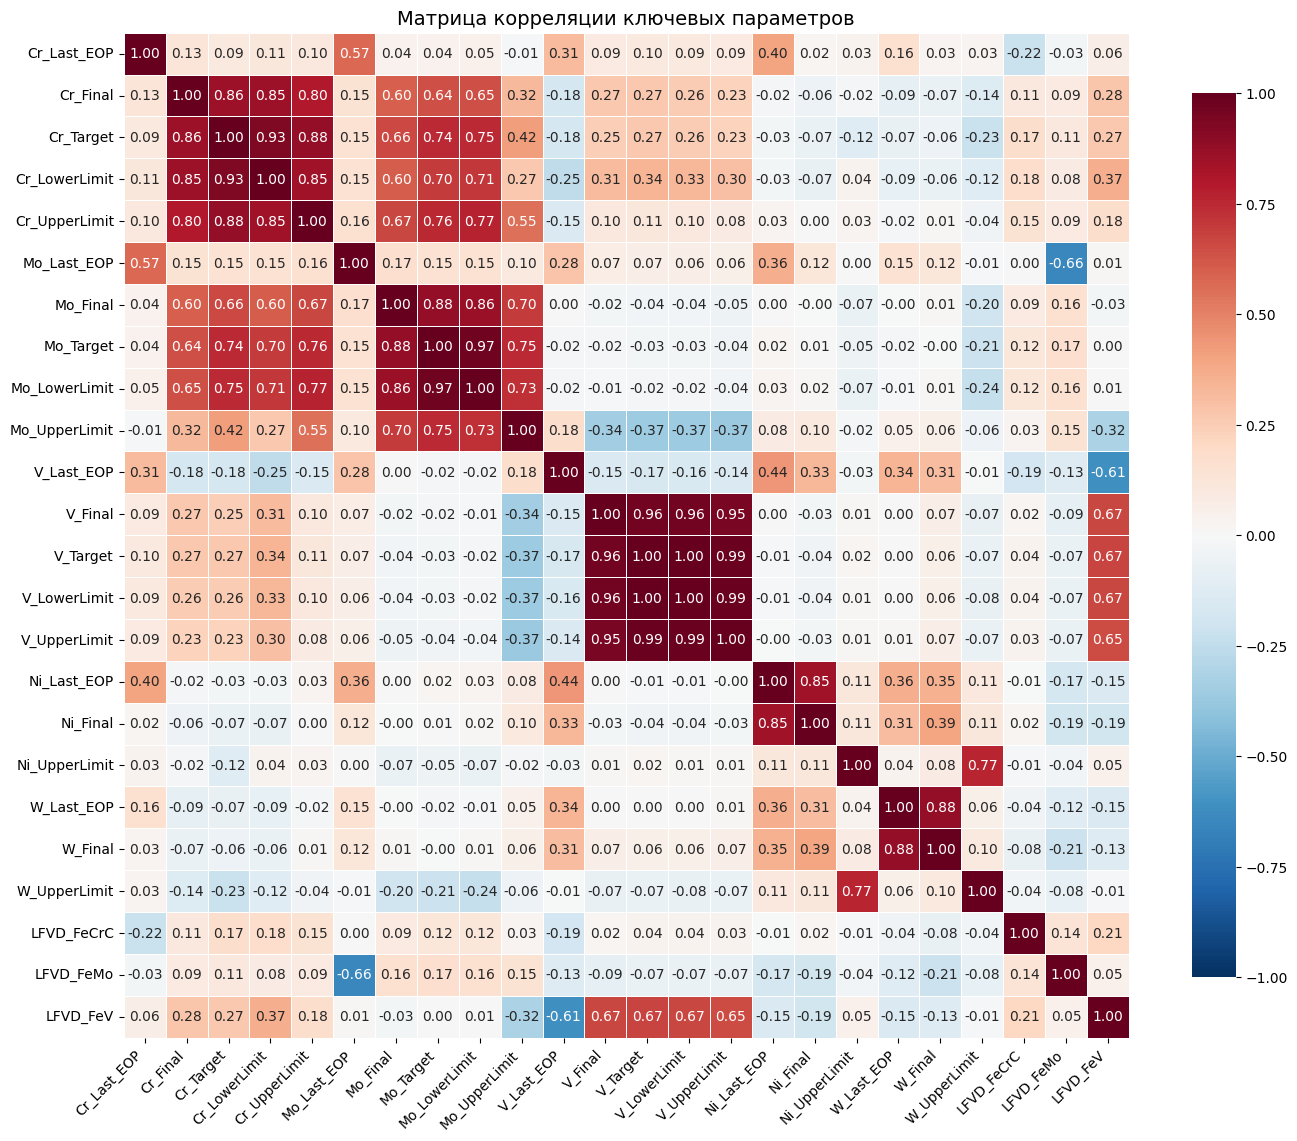

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

key_columns = [
    'Cr_Last_EOP', 'Cr_Final', 'Cr_Target', 'Cr_LowerLimit', 'Cr_UpperLimit',
    'Mo_Last_EOP', 'Mo_Final', 'Mo_Target', 'Mo_LowerLimit', 'Mo_UpperLimit',
    'V_Last_EOP', 'V_Final', 'V_Target', 'V_LowerLimit', 'V_UpperLimit',
    'Ni_Last_EOP', 'Ni_Final', 'Ni_UpperLimit',
    'W_Last_EOP', 'W_Final', 'W_UpperLimit',
    'LFVD_FeCrC', 'LFVD_FeMo', 'LFVD_FeV'
]

corr_selected = corr.loc[key_columns, key_columns]

plt.figure(figsize=(14, 12))

sns.heatmap(corr_selected,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            vmin=-1, vmax=1)

plt.title('Матрица корреляции ключевых параметров', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#Гистограммы отличия

Для начала построим гистограммы отличия процентного содержания каждого из контролируемых компонентов от минимального значения (показывает запас прочности - насколько мы выше минимально допустимого значения. Отрицательные значения = брак. Положительные значения показывают "запас", который можно потенциально сократить)



Среднее отклонение от нижней границы:
Cr: 0.2547
Mo: 0.0444
Ni: 0.1796
V:  0.0393
W:  0.0536


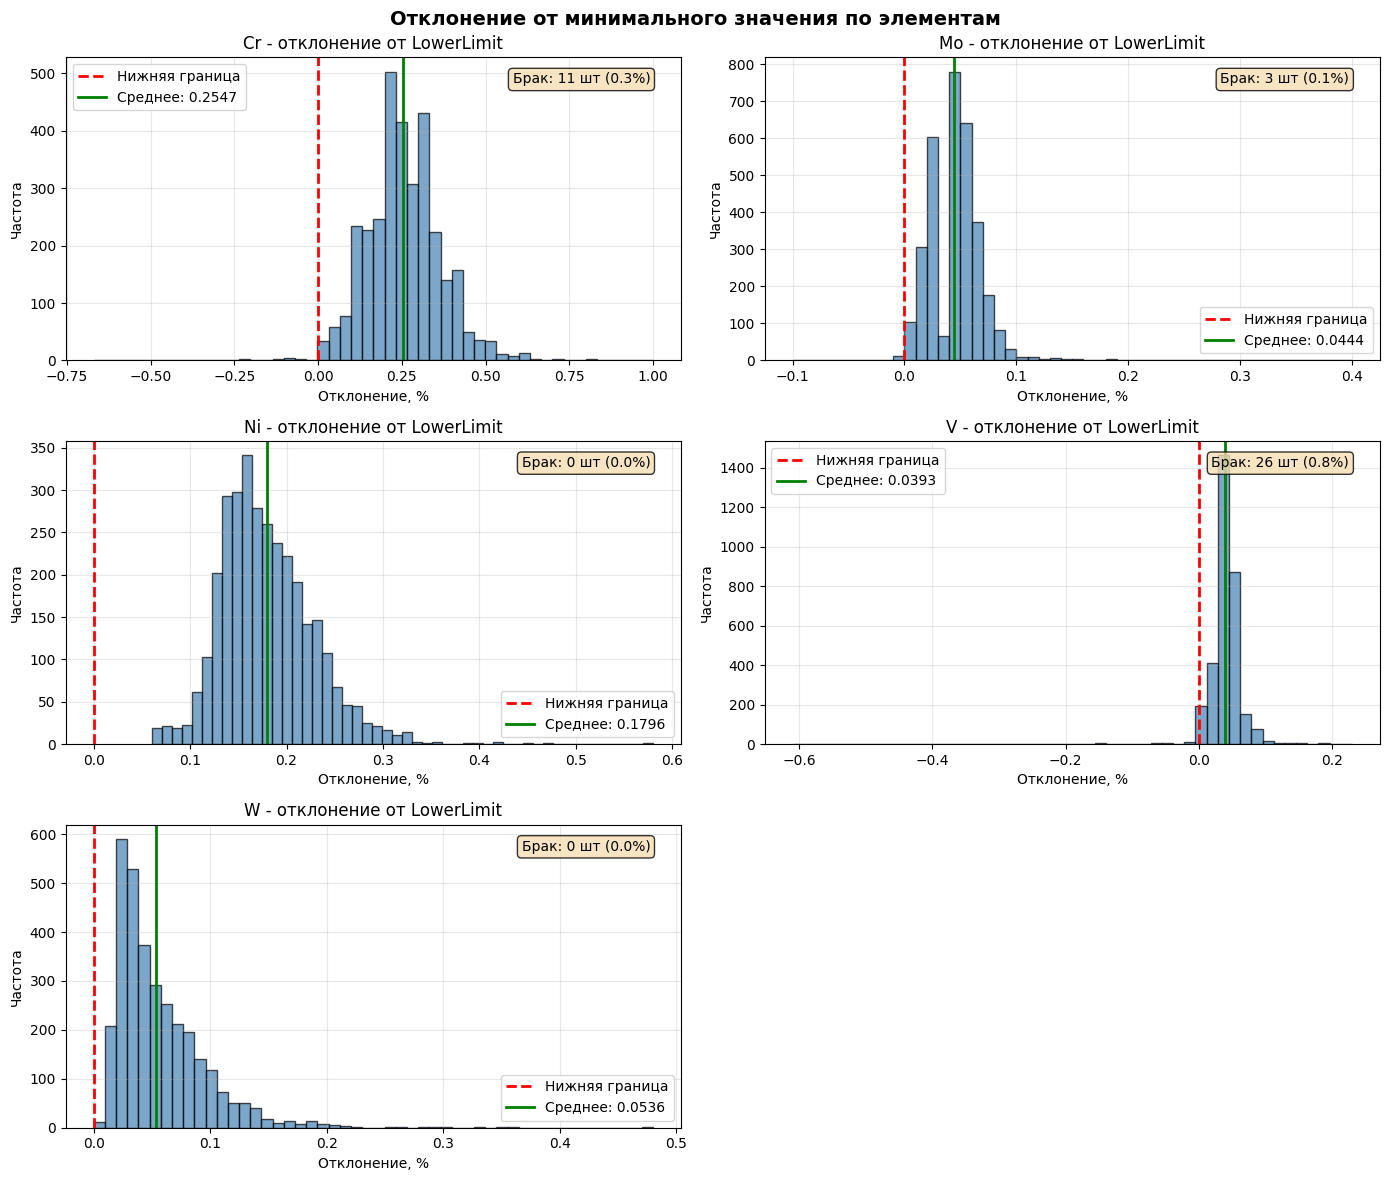

In [ ]:
import matplotlib.pyplot as plt

df['Cr_deviation'] = df['Cr_Final'] - df['Cr_LowerLimit']
df['Mo_deviation'] = df['Mo_Final'] - df['Mo_LowerLimit']
df['Ni_deviation'] = df['Ni_Final'] - df['Ni_LowerLimit']
df['V_deviation'] = df['V_Final'] - df['V_LowerLimit']
df['W_deviation'] = df['W_Final'] - df['W_LowerLimit']

print('Среднее отклонение от нижней границы:')
print(f'Cr: {df["Cr_deviation"].mean():.4f}')
print(f'Mo: {df["Mo_deviation"].mean():.4f}')
print(f'Ni: {df["Ni_deviation"].mean():.4f}')
print(f'V:  {df["V_deviation"].mean():.4f}')
print(f'W:  {df["W_deviation"].mean():.4f}')


fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()
elements = ['Cr', 'Mo', 'Ni', 'V', 'W']
deviations = [df['Cr_deviation'], df['Mo_deviation'],
              df['Ni_deviation'], df['V_deviation'],
              df['W_deviation']]

for i, (elem, dev) in enumerate(zip(elements, deviations)):
    ax = axes[i]
    ax.hist(dev, bins=50, edgecolor='black', alpha=0.7, color='steelblue') # гистограмма
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Нижняя граница') # вертикальная линия в нуле (граница брака)
    mean_val = dev.mean()
    ax.axvline(x=mean_val, color='green', linestyle='-', linewidth=2, label=f'Среднее: {mean_val:.4f}') # линия среднего значения
    ax.set_title(f'{elem} - отклонение от LowerLimit', fontsize=12)
    ax.set_xlabel('Отклонение, %')
    ax.set_ylabel('Частота')
    ax.legend()
    ax.grid(True, alpha=0.3)
    # Информация о браке
    defect = (dev < 0).sum()
    defect_pct = defect / len(dev) * 100
    ax.text(0.95, 0.95, f'Брак: {defect} шт ({defect_pct:.1f}%)',
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

fig.delaxes(axes[5])
plt.suptitle('Отклонение от минимального значения по элементам', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Далее построим гистограммы отличия процентного содержания каждого из контролируемых компонентов от целевого значения (положительное значение показывает перерасход феррасплава - выше цели получили содержание; отрицательное значение показывает недостаточное добавление ферросплава)

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df['Cr_exceed_target'] = df['Cr_Final'] - df['Cr_Target']
df['Ni_exceed_target'] = df['Ni_Final'] - df['Ni_Target']
df['Mo_exceed_target'] = df['Mo_Final'] - df['Mo_Target']
df['V_exceed_target'] = df['V_Final'] - df['V_Target']
df['W_exceed_target'] = df['W_Final'] - df['W_Target']

elements = {
    'Cr': {'data': df['Cr_exceed_target'], 'start': -0.2, 'end': 0.2},
    'Ni': {'data': df['Ni_exceed_target'], 'start': -0.5, 'end': 0.5},
    'Mo': {'data': df['Mo_exceed_target'], 'start': -0.2, 'end': 0.2},
    'V': {'data': df['V_exceed_target'], 'start': -0.2, 'end': 0.2},
    'W': {'data': df['W_exceed_target'], 'start': -0.2, 'end': 0.2}
}

for elem, settings in elements.items():
    fig = go.Figure()
    fig.add_trace(go.Histogram(
        x=settings['data'],
        xbins=dict(start=settings['start'], end=settings['end'], size=0.005),
        name=elem,
        marker_color='steelblue',
        opacity=0.8
    ))
    mean_val = settings['data'].mean()
    fig.add_vline(x=0, line_dash="dash", line_color="red", line_width=2)
    fig.add_vline(x=mean_val, line_dash="dash", line_color="green", line_width=2)
    fig.add_annotation(x=0, y=1, yref="paper",
                       text="Target", showarrow=False,
                       xanchor="left", yanchor="top",
                       font=dict(color="red"))
    fig.add_annotation(x=mean_val, y=0.95, yref="paper",
                       text=f"Среднее: {mean_val:.4f}", showarrow=False,
                       xanchor="left" if mean_val > 0 else "right", yanchor="top",
                       font=dict(color="green"))
    fig.update_layout(
        title=f'{elem}: отклонение от целевого значения',
        xaxis_title='Отклонение, %',
        yaxis_title='Количество плавок',
        showlegend=False,
        bargap=0.05
    )

    fig.show()

In [ ]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Histogram(x=df['Cr_exceed_target'], xbins=dict(start=-0.2, end=0.2, size=0.005), name='Отклонение от Target Cr'))
fig.add_trace(go.Histogram(x=df['Ni_exceed_target'], xbins=dict(start=-0.5, end=0.5, size=0.005), name='Отклонение от Target Ni'))
fig.add_trace(go.Histogram(x=df['Mo_exceed_target'], xbins=dict(start=-0.2, end=0.2, size=0.005), name='Отклонение от Target Mo'))
fig.add_trace(go.Histogram(x=df['V_exceed_target'], xbins=dict(start=-0.2, end=0.2, size=0.005), name='Отклонение от Target V'))
fig.add_trace(go.Histogram(x=df['W_exceed_target'], xbins=dict(start=-0.2, end=0.2, size=0.005), name='Отклонение от Target W'))

fig.show()

#Экономический эффект

Задание: определить возможный экономический эффект от разработки цифрового советчика. Предположим, что наш советчик сможет обеспечивать содержание Mo, Cr, Ni, V, W посередине между нижней границей и целевым значением (target).


Пояснение: поскольку модель еще не построена, для оценки потенциального эффекта будем исходить из гипотезы, что цифровой советчик будет рекомендовать такое количество ферросплавов, которое обеспечит содержание элементов (Mo, Cr, Ni, V, W) на уровне среднего арифметического между нижней границей допуска и целевым значением. Это соответствует стратегии работы на нижней границе требуемого диапазона, что позволяет минимизировать расход при сохранении соответствия требованиям качества.



In [ ]:
df['Cr_adviser_target'] = (df['Cr_Target'] + df['Cr_LowerLimit']) / 2
df['Ni_adviser_target'] = (df['Ni_Target'] + df['Ni_LowerLimit']) / 2
df['Mo_adviser_target'] = (df['Mo_Target'] + df['Mo_LowerLimit']) / 2
df['V_adviser_target'] = (df['V_Target'] + df['V_LowerLimit']) / 2
df['W_adviser_target'] = (df['W_Target'] + df['W_LowerLimit']) / 2

df['Cr_exceed_adviser'] = df['Cr_Final'] - df['Cr_adviser_target']
df['Ni_exceed_adviser'] = df['Ni_Final'] - df['Ni_adviser_target']
df['Mo_exceed_adviser'] = df['Mo_Final'] - df['Mo_adviser_target']
df['V_exceed_adviser'] = df['V_Final'] - df['V_adviser_target']
df['W_exceed_adviser'] = df['W_Final'] - df['W_adviser_target']

print('В среднем разница между Cr_Target и Cr_LowerLimit =', (df['Cr_Target'] - df['Cr_LowerLimit']).mean())
print('В среднем разница между Ni_Target и Ni_LowerLimit =', (df['Ni_Target'] - df['Ni_LowerLimit']).mean())
print('В среднем разница между Mo_Target и Mo_LowerLimit =', (df['Mo_Target'] - df['Mo_LowerLimit']).mean())
print('В среднем разница между V_Target и V_LowerLimit =', (df['V_Target'] - df['V_LowerLimit']).mean())
print('В среднем разница между W_Target и W_LowerLimit =', (df['W_Target'] - df['W_LowerLimit']).mean())



fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Histogram(x=df['Cr_exceed_adviser'], xbins=dict(start=-0.2, end=0.2, size=0.005), name='Гистограмма превышения Cr'))
fig.add_trace(go.Histogram(x=df['Ni_exceed_adviser'], xbins=dict(start=-0.5, end=0.5, size=0.005), name='Гистограмма превышения Ni'))
fig.add_trace(go.Histogram(x=df['Mo_exceed_adviser'], xbins=dict(start=-0.3, end=0.3, size=0.005), name='Гистограмма превышения Mo'))
fig.add_trace(go.Histogram(x=df['V_exceed_adviser'], xbins=dict(start=-0.3, end=0.3, size=0.005), name='Гистограмма превышения V'))
fig.add_trace(go.Histogram(x=df['W_exceed_adviser'], xbins=dict(start=-0.2, end=0.2, size=0.005), name='Гистограмма превышения W'))
fig.show()

В среднем разница между Cr_Target и Cr_LowerLimit = 0.26403100775193833
В среднем разница между Ni_Target и Ni_LowerLimit = 0.0
В среднем разница между Mo_Target и Mo_LowerLimit = 0.030927131782945757
В среднем разница между V_Target и V_LowerLimit = 0.041054263565891466
В среднем разница между W_Target и W_LowerLimit = 0.0


Выше видим визуальное подтверждение, что в большинстве плавок мы перерасходуем ферросплавы (смещение вправо относительно 0). Потенциал для экономии огромен

Рассмотрим потенциал экономии по элементам и визуализируем долю плавок с потенциалом экономии (в случае, если советчик будет обеспечивать содержание элементов посередине между нижней границей)

In [ ]:
print("Потенциал экономии (среднее превышение над советчиком) по элементам:")
print(f"  Cr : {df['Cr_exceed_adviser'].mean():+.4f}%")
print(f"  Ni : {df['Ni_exceed_adviser'].mean():+.4f}%")
print(f"  Mo : {df['Mo_exceed_adviser'].mean():+.4f}%")
print(f"  V  : {df['V_exceed_adviser'].mean():+.4f}%")
print(f"  W  : {df['W_exceed_adviser'].mean():+.4f}%")

print("\nЗначения показывают, на сколько % можно было бы в среднем снизить содержание элемента (а значит — расход соответствующего ферросплава), оставаясь в пределах допуска")


elements = ['Cr', 'Ni', 'Mo', 'V', 'W']
positive_shares = []
for elem in elements:
    exceed_col = f'{elem}_exceed_adviser'
    positive = (df[exceed_col] > 0).sum()
    share = positive / len(df) * 100
    positive_shares.append(share)
    print(f"{elem}: {positive} из {len(df)} плавок ({share:.1f}%) имеют потенциал экономии")

fig = go.Figure()
fig.add_trace(go.Bar(
    x=elements,
    y=positive_shares,
    marker_color='#ff6b6b',
    text=[f'{x:.1f}%' for x in positive_shares],
    textposition='auto'
))

fig.update_layout(
    title='Доля плавок с потенциалом экономии',
    xaxis_title='Элемент',
    yaxis_title='Доля плавок, %',
    height=500
)
fig.show()

Потенциал экономии (среднее превышение над советчиком) по элементам:
  Cr : +0.1227%
  Ni : +0.1796%
  Mo : +0.0289%
  V  : +0.0188%
  W  : +0.0536%

Значения показывают, на сколько % можно было бы в среднем снизить содержание элемента (а значит — расход соответствующего ферросплава), оставаясь в пределах допуска
Cr: 2932 из 3225 плавок (90.9%) имеют потенциал экономии
Ni: 3225 из 3225 плавок (100.0%) имеют потенциал экономии
Mo: 3083 из 3225 плавок (95.6%) имеют потенциал экономии
V: 2717 из 3225 плавок (84.2%) имеют потенциал экономии
W: 3214 из 3225 плавок (99.7%) имеют потенциал экономии


Посчитаем в деньгах экономический эффект

In [ ]:
print(df[['TotalIngotsWeight','Cr_Last_EOP','Cr_Final','LFVD_FeCrA','LFVD_FeCrC']].head(3))
print('Кол-во строк с большим исходным составом =',len(df[(df['LFVD_FeCrA']==0)&(df['LFVD_FeCrC']==0)&(df['LFVD_FeCrCSi']==0)&(df['LFVD_FeCrC51']==0)]))

   TotalIngotsWeight  Cr_Last_EOP  Cr_Final  LFVD_FeCrA  LFVD_FeCrC
0            49440.0         9.71     11.30           0        2400
1            46800.0        12.41     11.75           0        1200
2            45320.0        11.24     11.63           0        2000
Кол-во строк с большим исходным составом = 235


In [ ]:
data_cr = df[(df['Cr_Final'] > df['Cr_Last_EOP']) & (df['Cr_Final'] > df['Cr_Target'])]
data_cr = data_cr.copy()

data_cr['FeCr_1%'] = ((data_cr['LFVD_FeCrA']+data_cr['LFVD_FeCrC']) / (data_cr['Cr_Final'] - data_cr['Cr_Last_EOP']) / data_cr['TotalIngotsWeight'] * 100)

data_cr['Cr_surplus'] = ((data_cr['LFVD_FeCrA'] + data_cr['LFVD_FeCrC']) - (data_cr['Cr_Target']-data_cr['Cr_Last_EOP'])
* data_cr['TotalIngotsWeight'] * data_cr['FeCr_1%'] / 100)

display(data_cr[['TotalIngotsWeight','Cr_Last_EOP','Cr_Target','Cr_Final','LFVD_FeCrA','LFVD_FeCrC','FeCr_1%','Cr_surplus']].head(3))
print('Перерасход в год FeCr =',round(data_cr['Cr_surplus'].sum()/10,0),'кг','примерная стоимость =',round(data_cr['Cr_surplus'].sum()/10*300/1000000,2),
      'млн.руб')

,TotalIngotsWeight,Cr_Last_EOP,Cr_Target,Cr_Final,LFVD_FeCrA,LFVD_FeCrC,FeCr_1%,Cr_surplus
0,49440.0,9.71,11.26,11.30,0,2400,3.053062,60.377358
7,51460.0,10.54,11.26,11.45,0,1300,2.776081,271.428571
9,46800.0,9.95,11.76,11.79,0,600,0.696767,9.782609


Перерасход в год FeCr = 8264.0 кг примерная стоимость = 2.48 млн.руб


Просчитаем стоимость перерасхода если нам удастся обеспечить среднее значение между Cr_LowerLimit и Cr_Target (благодаря советчику)

In [ ]:
data_cr_adv = df[(df['Cr_Final'] > df['Cr_Last_EOP']) & (df['Cr_Final'] > (df['Cr_LowerLimit'] + df['Cr_Target'])/2) &
                 ((df['LFVD_FeCrA'] + df['LFVD_FeCrC']) > 0)].copy()

data_cr_adv['Cr_adviser_target'] = (data_cr_adv['Cr_Target'] + data_cr_adv['Cr_LowerLimit']) / 2

data_cr_adv['FeCr_1%'] = ((data_cr_adv['LFVD_FeCrA'] + data_cr_adv['LFVD_FeCrC']) / (data_cr_adv['Cr_Final'] - data_cr_adv['Cr_Last_EOP']) /
                           data_cr_adv['TotalIngotsWeight'] * 100)

data_cr_adv['FeCr_surplus_adv'] = ((data_cr_adv['LFVD_FeCrA'] + data_cr_adv['LFVD_FeCrC']) -
                                  ((data_cr_adv['Cr_adviser_target'] - data_cr_adv['Cr_Last_EOP']) *
                                    data_cr_adv['TotalIngotsWeight'] * data_cr_adv['FeCr_1%'] / 100))

display(data_cr_adv[['TotalIngotsWeight','Cr_Last_EOP','Cr_adviser_target', 'Cr_Final','LFVD_FeCrA','LFVD_FeCrC','FeCr_1%','FeCr_surplus_adv']].head(3))

print(f'Потенциальная экономия FeCr благодаря советчику = {round(data_cr_adv['FeCr_surplus_adv'].sum()/10, 0)} кг в год')
print(f'Примерная стоимость экономии (перерасход, который можем устранить)= {round(data_cr_adv['FeCr_surplus_adv'].sum()/10 * 300 / 1000000, 2)} млн.руб в год')

,TotalIngotsWeight,Cr_Last_EOP,Cr_adviser_target,Cr_Final,LFVD_FeCrA,LFVD_FeCrC,FeCr_1%,FeCr_surplus_adv
0,49440.0,9.71,11.180,11.30,0,2400,3.053062,181.132075
2,45320.0,11.24,11.575,11.63,0,2000,11.315545,282.051282
4,48410.0,10.02,11.230,11.29,0,1250,2.033158,59.055118


Потенциальная экономия FeCr благодаря советчику = 34580.0 кг в год
Примерная стоимость экономии (перерасход, который можем устранить)= 10.37 млн.руб в год


Выполним расчеты потенциальной экономии (перерасхода) для каждого элемента: Mo, Ni, V, W (в данном случае буду выполнять расчет перерасхода относительно табличного таргета, а не совета модели)

Расчёт для Mo


,TotalIngotsWeight,Mo_Last_EOP,Mo_Target,Mo_Final,LFVD_FeMo,LFVD_Polymox,Mo_1%,Mo_surplus
1,46800.0,0.08,0.73,0.85,625,0,1.734377,97.402597
5,43800.0,0.46,0.73,0.75,235,0,1.850102,16.206897
6,48100.0,0.50,0.73,0.74,195,0,1.689189,8.125000


Количество плавок с перерасходом: 1963
Перерасход ферросплавов с Mo в год ≈ 4399.3 кг
Примерная стоимость перерасхода ≈ 5.27918 млн руб/год

Расчёт для Ni


,TotalIngotsWeight,Ni_Last_EOP,Ni_Target,Ni_Final,LFVD_NiGran,Ni_1%,Ni_surplus
2214,44240.0,0.0,0,0.1,15,0.33906,15.0


Количество плавок с перерасходом: 1
Перерасход ферросплавов с Ni в год ≈ 1.5 кг
Примерная стоимость перерасхода ≈ 0.0027 млн руб/год

Расчёт для V


,TotalIngotsWeight,V_Last_EOP,V_Target,V_Final,LFVD_FeV,V_1%,V_surplus
6,48100.0,0.38,0.76,0.77,240,1.279386,6.153846
8,48960.0,0.31,0.66,0.69,235,1.263115,18.552632
9,46800.0,0.05,0.30,0.33,160,1.221001,17.142857


Количество плавок с перерасходом: 1046
Перерасход ферросплавов с V в год ≈ 1229.3 кг
Примерная стоимость перерасхода ≈ 3.07336 млн руб/год

Расчёт для W


,TotalIngotsWeight,W_Last_EOP,W_Target,W_Final,LFVD_FeW72,W_1%,W_surplus
549,43870.0,0.01,0,0.02,20,4.558924,40.0
808,48280.0,0.14,0,0.16,5,0.517813,40.0
892,49000.0,0.05,0,0.08,9,0.612245,24.0


Количество плавок с перерасходом: 4
Перерасход ферросплавов с W в год ≈ 19.4 кг
Примерная стоимость перерасхода ≈ 0.0679 млн руб/год



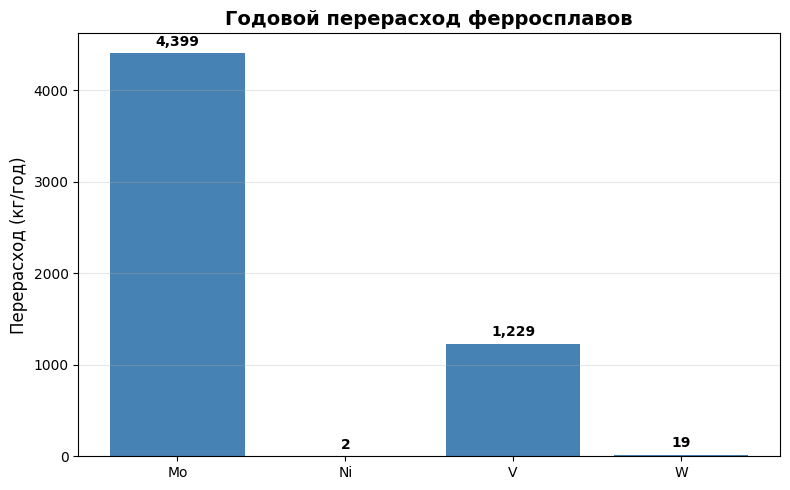

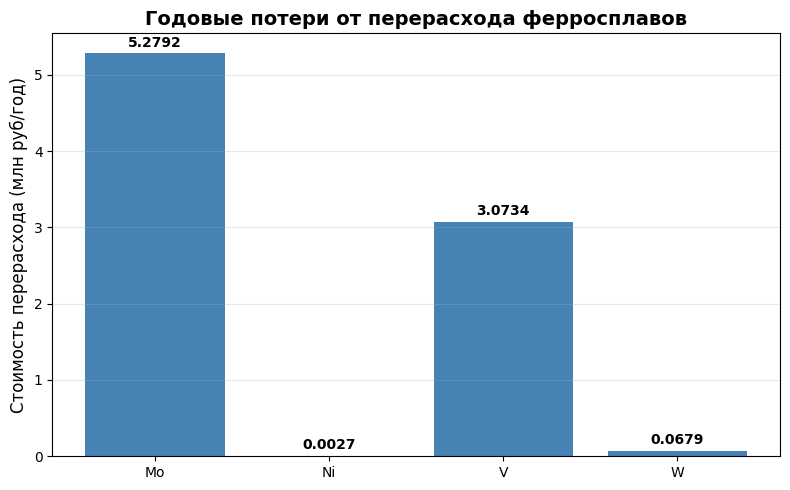

In [ ]:
Cost_for_kg = {'Mo': 1200, 'Ni': 1800, 'V': 2500, 'W': 3500, 'Cr': 300}
elements = ['Mo', 'Ni', 'V', 'W']

results = []
costs = []
for el in elements:
    print(f"Расчёт для {el}")
    last_eop   = f"{el}_Last_EOP"
    target     = f"{el}_Target"
    final      = f"{el}_Final"
    lower      = f"{el}_LowerLimit"
    alloy_cols = {
        'Mo': ['LFVD_FeMo', 'LFVD_Polymox'],
        'Ni': ['LFVD_NiGran'],
        'V':  ['LFVD_FeV'],
        'W':  ['LFVD_FeW72']}[el]
    alloy_sum_col = f"LFVD_{el}_add"
    df[alloy_sum_col] = df[alloy_cols].sum(axis=1)

    mask = ((df[final] > df[last_eop]) & (df[final] > df[target]) & (df[alloy_sum_col] > 0))
    data_el = df[mask].copy()

    data_el[f'{el}_1%'] = (data_el[alloy_sum_col] / (data_el[final] - data_el[last_eop]) / data_el['TotalIngotsWeight'] * 100)

    required_alloy = (data_el[target] - data_el[last_eop]) * data_el['TotalIngotsWeight'] * data_el[f'{el}_1%'] / 100
    data_el[f'{el}_surplus'] = data_el[alloy_sum_col] - required_alloy

    show_cols = ['TotalIngotsWeight', last_eop, target, final] + alloy_cols + [f'{el}_1%', f'{el}_surplus']
    display(data_el[show_cols].head(3))
    total_surplus_kg = data_el[f'{el}_surplus'].sum()
    year_surplus_kg  = total_surplus_kg / 10
    results.append(year_surplus_kg)
    year_cost_mrub   = round(year_surplus_kg * Cost_for_kg[el] / 1_000_000, 5)
    costs.append(year_cost_mrub)
    print(f"Количество плавок с перерасходом: {len(data_el)}")
    print(f"Перерасход ферросплавов с {el} в год ≈ {round(year_surplus_kg, 1)} кг")
    print(f"Примерная стоимость перерасхода ≈ {year_cost_mrub} млн руб/год\n")


plt.figure(figsize=(8, 5))
bars = plt.bar(elements, results, color='steelblue')
plt.ylabel('Перерасход (кг/год)', fontsize=12)
plt.title('Годовой перерасход ферросплавов', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, results):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
bars = plt.bar(elements, costs, color='steelblue')
plt.ylabel('Стоимость перерасхода (млн руб/год)', fontsize=12)
plt.title('Годовые потери от перерасхода ферросплавов', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, costs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()